# How Wrong Is Your MMM? — Diagnostic Walkthrough

**Audience:** internal / building intuition  
**Purpose:** show that collinear spend channels make OLS elasticity estimates unreliable, and quantify how bad it gets.

This notebook has two sections:
1. **Sweep correlation** — as inter-channel correlation increases, how much does estimate reliability deteriorate?
2. **Fixed correlation, many seeds** — same market, same true elasticities, 50 different data periods. How different are the answers?

Section 3 (real spend data) is a later sprint.


In [11]:
# config
FAST_MODE = False   # set False for publication-quality runs (50 sims per level)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from how_wrong_is_your_mmm import CollinearityDiagnostic, simulate_spend, simulate_sales, fit_ols


## The setup

Two channels: **TV** and **Meta**. Both track the same underlying demand signal — when consumer demand rises, both budgets go up. That's realistic: marketing plans follow demand forecasts.

True elasticities: TV = 0.3, Meta = 0.5. These are the numbers a perfect MMM would recover.

We simulate sales as: `sales = base + 0.3 × TV + 0.5 × Meta + noise`

Then fit OLS: `sales ~ TV + Meta`

If OLS is working, it should recover 0.3 and 0.5. Let's see how well it does as correlation increases.


In [13]:
# single run at correlation 0.7 to show the setup
spend = simulate_spend(n_obs=104, correlation=0.7, seed=0)
print(f"TV/Meta correlation: {spend['tv'].corr(spend['meta']):.2f}")
print(f"TV spend range:   £{spend['tv'].min():,.0f} – £{spend['tv'].max():,.0f}")
print(f"Meta spend range: £{spend['meta'].min():,.0f} – £{spend['meta'].max():,.0f}")


TV/Meta correlation: 0.63
TV spend range:   £52,159 – £153,003
Meta spend range: £34,352 – £133,152


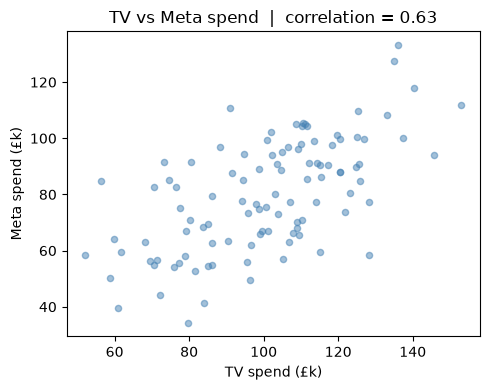

In [14]:
# show how correlated the channels are
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(spend["tv"] / 1000, spend["meta"] / 1000, alpha=0.5, color="steelblue", s=20)
ax.set_xlabel("TV spend (£k)")
ax.set_ylabel("Meta spend (£k)")
ax.set_title(f"TV vs Meta spend  |  correlation = {spend['tv'].corr(spend['meta']):.2f}")
plt.tight_layout()
plt.show()


## Section 1 — Sweep correlation

For each correlation level (0.1 → 0.9), run N simulations with different seeds.  
Each simulation is a different "period" of data from the same market.  
Collect the estimated elasticities across simulations and plot the distribution.


In [15]:
n_sims = 10 if FAST_MODE else 50
correlations = np.round(np.arange(0.1, 0.95, 0.1), 1).tolist()

results = []
for corr in correlations:
    diag = CollinearityDiagnostic(correlation=corr, spend_seed=0)
    diag.fit(n_sims=n_sims, fast_mode=FAST_MODE)
    df = diag.results_.copy()
    df["target_correlation"] = corr
    df["actual_correlation"] = round(diag.actual_correlation, 2)
    results.append(df)

all_results = pd.concat(results, ignore_index=True)
print(f"Total simulations: {len(all_results)}")
all_results.head()


Total simulations: 900


,sim,channel,true_elasticity,estimated_elasticity,error,error_pct,target_correlation,actual_correlation
0,0,tv,0.3,0.370613,0.070613,23.537545,0.1,-0.06
1,0,meta,0.5,0.651838,0.151838,30.367523,0.1,-0.06
2,1,tv,0.3,0.307839,0.007839,2.612866,0.1,-0.06
3,1,meta,0.5,0.463566,-0.036434,-7.286786,0.1,-0.06
4,2,tv,0.3,0.295529,-0.004471,-1.490295,0.1,-0.06


In [16]:
# summary table: how does std_estimated grow with correlation?
summary_rows = []
for corr in correlations:
    sub = all_results[all_results["target_correlation"] == corr]
    for ch in ("tv", "meta"):
        s = sub[sub["channel"] == ch]
        summary_rows.append({
            "target_corr": corr,
            "channel": ch,
            "true": s["true_elasticity"].iloc[0],
            "mean_est": s["estimated_elasticity"].mean(),
            "std_est": s["estimated_elasticity"].std(),
            "cv": s["estimated_elasticity"].std() / abs(s["estimated_elasticity"].mean()),
        })

sweep_summary = pd.DataFrame(summary_rows).round(3)
print(sweep_summary.to_string(index=False))


 target_corr channel  true  mean_est  std_est    cv
         0.1      tv   0.3     0.305    0.031 0.100
         0.1    meta   0.5     0.500    0.041 0.082
         0.2      tv   0.3     0.307    0.047 0.153
         0.2    meta   0.5     0.499    0.060 0.120
         0.3      tv   0.3     0.309    0.061 0.198
         0.3    meta   0.5     0.498    0.075 0.151
         0.4      tv   0.3     0.310    0.075 0.241
         0.4    meta   0.5     0.497    0.089 0.179
         0.5      tv   0.3     0.312    0.089 0.284
         0.5    meta   0.5     0.496    0.103 0.207
         0.6      tv   0.3     0.314    0.104 0.331
         0.6    meta   0.5     0.494    0.118 0.238
         0.7      tv   0.3     0.316    0.122 0.385
         0.7    meta   0.5     0.491    0.136 0.278
         0.8      tv   0.3     0.319    0.148 0.463
         0.8    meta   0.5     0.486    0.166 0.341
         0.9      tv   0.3     0.325    0.200 0.615
         0.9    meta   0.5     0.477    0.231 0.484


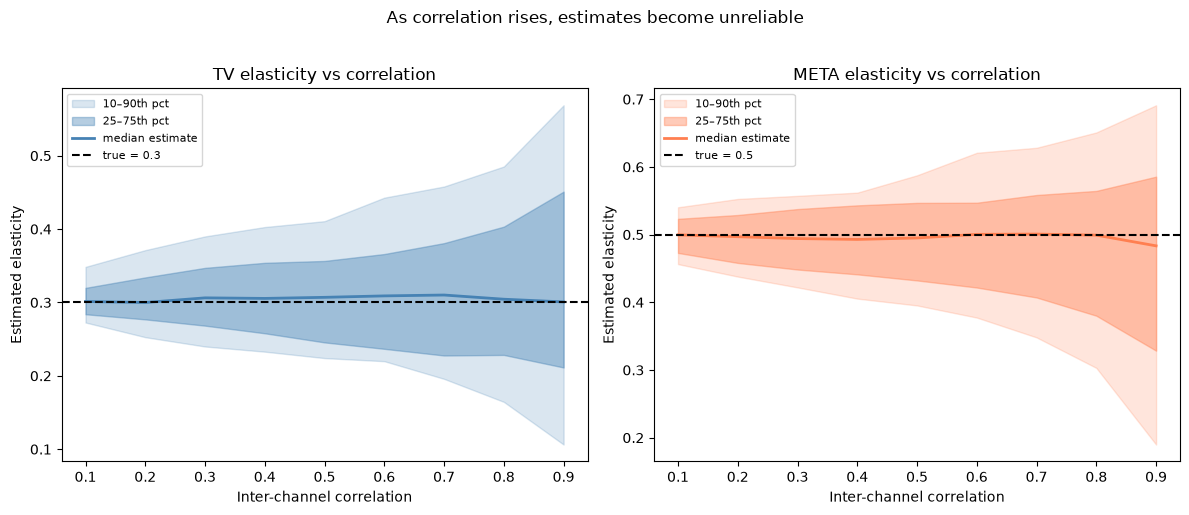

In [17]:
# plot: distribution of estimates vs correlation level
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, channel, true_e, color in zip(
    axes, ["tv", "meta"], [0.3, 0.5], ["steelblue", "coral"]
):
    sub = all_results[all_results["channel"] == channel]
    
    medians = sub.groupby("target_correlation")["estimated_elasticity"].median()
    q25 = sub.groupby("target_correlation")["estimated_elasticity"].quantile(0.25)
    q75 = sub.groupby("target_correlation")["estimated_elasticity"].quantile(0.75)
    q10 = sub.groupby("target_correlation")["estimated_elasticity"].quantile(0.10)
    q90 = sub.groupby("target_correlation")["estimated_elasticity"].quantile(0.90)

    ax.fill_between(correlations, q10, q90, alpha=0.2, color=color, label="10–90th pct")
    ax.fill_between(correlations, q25, q75, alpha=0.4, color=color, label="25–75th pct")
    ax.plot(correlations, medians, color=color, linewidth=2, label="median estimate")
    ax.axhline(true_e, color="black", linestyle="--", linewidth=1.5, label=f"true = {true_e}")
    
    ax.set_xlabel("Inter-channel correlation")
    ax.set_ylabel("Estimated elasticity")
    ax.set_title(f"{channel.upper()} elasticity vs correlation")
    ax.legend(fontsize=8)

plt.suptitle("As correlation rises, estimates become unreliable", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**What this shows:** the median estimate stays close to the true value (OLS is unbiased), but the spread explodes as correlation increases. At correlation 0.9 the interquartile range is huge — you could easily get an estimate that's double or half the true value just by chance.

This is the problem in one chart. Same market. Same truth. Different answers depending on your data.


## Section 2 — Fixed correlation, many seeds

Now fix correlation at 0.7 (a realistic level for TV and Meta following the same campaign calendar).  
Run 50 different seeds — 50 different "periods" of data from the same market.  
Each one gives a different estimated elasticity.


In [18]:
diag_fixed = CollinearityDiagnostic(correlation=0.7, spend_seed=0)
diag_fixed.fit(n_sims=n_sims, fast_mode=FAST_MODE)

print(f"Actual TV/Meta correlation: {diag_fixed.actual_correlation:.2f}")
print()
print(diag_fixed.summary().to_string(index=False))


Actual TV/Meta correlation: 0.63

channel  true_elasticity  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta              0.5          0.4909         0.1365         -1.8266             0.2780
     tv              0.3          0.3157         0.1217          5.2283             0.3855


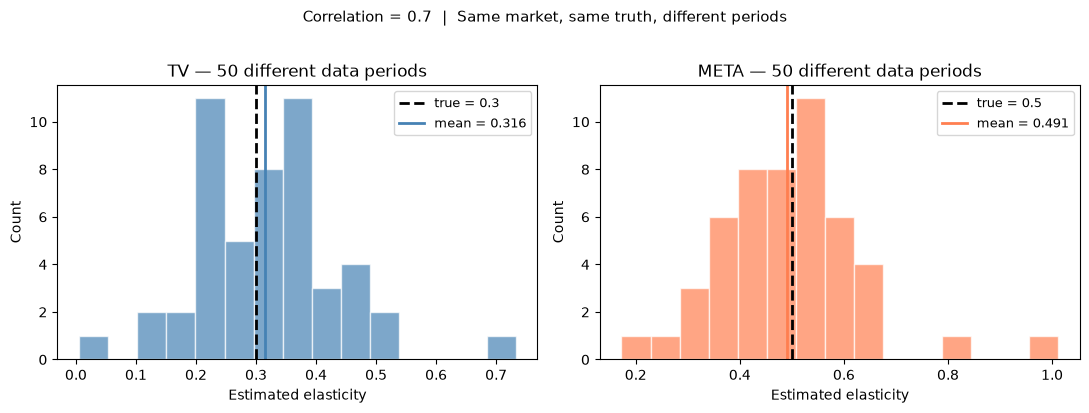

In [19]:
# plot: distribution of estimates across 50 seeds
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, channel, true_e, color in zip(
    axes, ["tv", "meta"], [0.3, 0.5], ["steelblue", "coral"]
):
    estimates = diag_fixed.results_[diag_fixed.results_["channel"] == channel]["estimated_elasticity"]
    
    ax.hist(estimates, bins=15, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(true_e, color="black", linestyle="--", linewidth=2, label=f"true = {true_e}")
    ax.axvline(estimates.mean(), color=color, linestyle="-", linewidth=2, label=f"mean = {estimates.mean():.3f}")
    
    ax.set_xlabel("Estimated elasticity")
    ax.set_ylabel("Count")
    ax.set_title(f"{channel.upper()} — 50 different data periods")
    ax.legend(fontsize=9)

plt.suptitle("Correlation = 0.7  |  Same market, same truth, different periods", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [20]:
# show the range practically
for channel, true_e in [("tv", 0.3), ("meta", 0.5)]:
    estimates = diag_fixed.results_[diag_fixed.results_["channel"] == channel]["estimated_elasticity"]
    lo, hi = estimates.quantile(0.1), estimates.quantile(0.9)
    print(f"{channel.upper():5s}  true={true_e:.1f}  80% range: [{lo:.3f}, {hi:.3f}]  width={hi-lo:.3f}")


TV     true=0.3  80% range: [0.196, 0.458]  width=0.262
META   true=0.5  80% range: [0.348, 0.628]  width=0.280


**The "so what":** if your TV and Meta spend are 70% correlated (typical for channels following the same campaign calendar), your estimated TV elasticity could plausibly be anywhere in that range — just depending on which period of data you happened to use.

That's why the model gives different answers every quarter when you refit with new data. It's not the model, and it's not the analyst. It's the data design.

**The fix:** deliberately de-correlate the channels by varying the budget mix — more TV in some periods, more Meta in others. That's the budget perturbation (next sprint).
